# DINO의 EMA(지수이동평균) — teacher는 왜 student의 "느린 평균"인가

DINO에는 EMA가 세 군데 들어간다.

| 위치 | 원본 코드 | 모멘텀 $m$ |
|---|---|---|
| **teacher 파라미터** = student 파라미터의 EMA | [main_dino.py:346](../main_dino.py#L346) `param_k.mul_(m).add_((1-m)*param_q)` | 0.996 → 1 (cosine) |
| **center** = teacher 출력 배치 평균의 EMA | [main_dino.py:416](../main_dino.py#L416) `self.center * 0.9 + batch_center * 0.1` | 0.9 |
| (참고) 옵티마이저 모멘텀 = gradient의 EMA | `torch.optim.AdamW` / `SGD(momentum=0.9)` | 0.9 |

이 노트북은 첫 번째, **teacher = student의 EMA** 를 중심으로 EMA가 정확히 무엇을 계산하는지,
$m$이 0.996이라는 숫자가 무슨 뜻인지, 왜 학습 중에 1로 올리는지를 **숫자와 그림으로** 확인한다.
마지막에 center의 EMA(0.9)가 왜 전혀 다른 값인지도 본다.

읽는 순서:

1. **EMA 한 줄 정의** — 노이즈를 얼마나 걸러내나
2. **풀어 쓰기** — 과거를 기하급수 가중치로 평균한다. "유효 창(window) ≈ 1/(1−m)"
3. **지연(lag)과 초기화 편향** — EMA의 대가. DINO는 teacher를 student 복사본으로 초기화해 편향을 없앤다
4. **파라미터 EMA** — 원본 코드 한 줄을 1:1로 재현
5. **토이 실험** — EMA teacher가 student보다 왜 더 좋은 모델인가 (Polyak 평균)
6. **모멘텀 스케줄** — 0.996 → 1 cosine. 배치 크기와의 관계
7. **center의 EMA** — 같은 EMA인데 왜 0.9인가
8. **요약 + 실전 함정**

의존성: `torch`, `numpy`, `matplotlib`. GPU 불필요, 전체 실행 1분 이내.

In [1]:
import math, copy, sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.unicode_minus": False})

# 저장소 루트를 sys.path에 넣어 utils.cosine_scheduler를 원본 그대로 쓴다 (6절)
REPO = Path.cwd().resolve()
while not (REPO / "main_dino.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / "main_dino.py").exists(), "dino 저장소 안에서 실행하세요"
sys.path.insert(0, str(REPO))
import utils

print("repo :", REPO)
print("torch:", torch.__version__)

repo : /home/sungwoo/projects/swcho/dino
torch: 2.4.0+cu121


## 1. EMA 한 줄 정의

입력 열 $x_1, x_2, \dots$ 가 들어올 때, EMA $y_t$는

$$y_t = m\,y_{t-1} + (1-m)\,x_t$$

한 줄이 전부다. "이전 값을 $m$만큼 남기고, 새 값을 $(1-m)$만큼 섞는다."
원본의 `param_k.mul_(m).add_((1-m)*param_q)`가 정확히 이 식이다 (`param_k`=teacher=$y$, `param_q`=student=$x$).

먼저 스칼라로 감을 잡자. 참값 1.0 주위에서 노이즈 치는 신호를 EMA로 걸러본다.

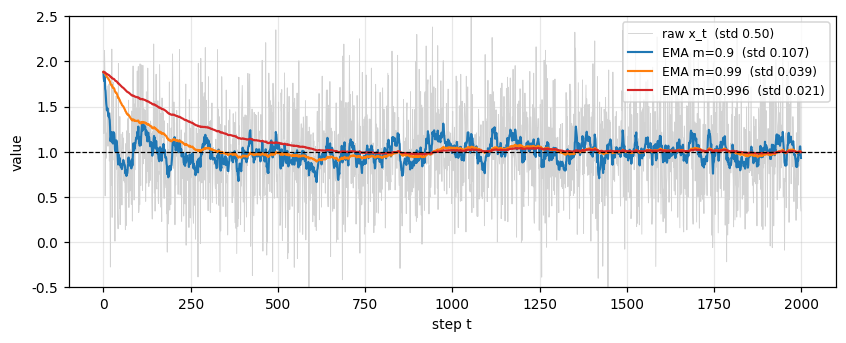

In [2]:
def ema(xs, m, init=None):
    """xs: 1-D 시퀀스. init=None이면 첫 값으로 초기화(DINO 방식), 아니면 그 값에서 시작."""
    ys = np.empty_like(xs, dtype=float)
    y = xs[0] if init is None else init
    for t, x in enumerate(xs):
        y = m * y + (1 - m) * x
        ys[t] = y
    return ys

T = 2000
x = 1.0 + np.random.randn(T) * 0.5          # 참값 1.0 + 노이즈(std 0.5)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(x, c="lightgray", lw=.6, label="raw x_t  (std 0.50)")
for m, c in [(0.9, "C0"), (0.99, "C1"), (0.996, "C3")]:
    y = ema(x, m)
    ax.plot(y, c=c, lw=1.4, label=f"EMA m={m}  (std {y[500:].std():.3f})")
ax.axhline(1.0, ls="--", c="k", lw=.8)
ax.set_xlabel("step t"); ax.set_ylabel("value"); ax.set_ylim(-0.5, 2.5)
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=.3)
plt.show()

$m$이 1에 가까울수록 노이즈가 강하게 걸러진다. 하지만 공짜가 아니다 — $m$=0.996 곡선은 **첫 샘플 값(우연히 ≈1.9)에서 출발해 1.0에 닿기까지 수백 스텝**이 걸린다.
이 "느림"이 3절의 지연(lag)이다.

노이즈가 얼마나 줄었는지 이론값과 비교해 보자. 독립 노이즈(분산 $\sigma^2$)를 EMA하면 정상상태 분산은

$$\mathrm{Var}(y) = \sigma^2 \frac{1-m}{1+m}$$

In [3]:
sigma = 0.5
print(f"{'m':>7} {'measured std':>13} {'theory std':>11}")
for m in [0.9, 0.99, 0.996, 0.9995]:
    y = ema(1.0 + np.random.randn(200_000) * sigma, m)
    print(f"{m:>7} {y[20_000:].std():>13.4f} {sigma * math.sqrt((1 - m) / (1 + m)):>11.4f}")

      m  measured std  theory std
    0.9        0.1139      0.1147
   0.99        0.0344      0.0354
  0.996        0.0226      0.0224
 0.9995        0.0080      0.0079


## 2. 풀어 쓰기 — EMA는 "기하급수 가중 평균"이다

재귀식을 계속 풀면

$$y_t = (1-m)\sum_{k=0}^{\infty} m^k\, x_{t-k}$$

즉 **최근 값에 $(1-m)$, 한 스텝 전에 $(1-m)m$, 두 스텝 전에 $(1-m)m^2$ …** 의 가중치를 준 평균이다.
가중치의 합은 $(1-m)(1+m+m^2+\cdots) = 1$ 이므로 정확히 평균이다.

"몇 스텝을 평균하는 것과 비슷한가"를 말하는 지표들:

| 지표 | 식 | 뜻 |
|---|---|---|
| 유효 창(window) | $1/(1-m)$ | 가중치의 평균 나이. "최근 이만큼을 평균"과 대략 동치 |
| 반감기 | $\ln 0.5 / \ln m$ | 가중치가 절반으로 줄기까지 스텝 |
| 95% 창 | $\ln 0.05 / \ln m$ | 가중치 질량의 95%가 이 안에 있다 |

In [4]:
def window(m):    return 1 / (1 - m)
def half_life(m): return math.log(0.5) / math.log(m)
def w95(m):       return math.log(0.05) / math.log(m)

print(f"{'m':>7} {'window 1/(1-m)':>15} {'half-life':>10} {'95% window':>11}   DINO에서의 의미")
notes = {0.9: "center_momentum", 0.99: "", 0.996: "momentum_teacher (batch 1024)",
         0.9995: "권장값, batch 256", 0.9999: "학습 후반"}
for m in notes:
    print(f"{m:>7} {window(m):>15.0f} {half_life(m):>10.0f} {w95(m):>11.0f}   {notes[m]}")

      m  window 1/(1-m)  half-life  95% window   DINO에서의 의미
    0.9              10          7          28   center_momentum
   0.99             100         69         298   
  0.996             250        173         747   momentum_teacher (batch 1024)
 0.9995            2000       1386        5990   권장값, batch 256
 0.9999           10000       6931       29956   학습 후반


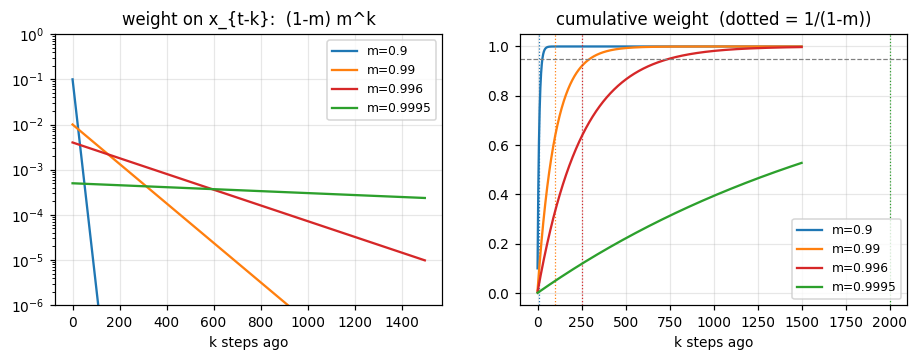

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
k = np.arange(0, 1500)
for m, c in [(0.9, "C0"), (0.99, "C1"), (0.996, "C3"), (0.9995, "C2")]:
    w = (1 - m) * m ** k
    axes[0].plot(k, w, c=c, label=f"m={m}")
    axes[1].plot(k, np.cumsum(w), c=c, label=f"m={m}")
    axes[1].axvline(window(m), c=c, ls=":", lw=.8)
axes[0].set_yscale("log"); axes[0].set_ylim(1e-6, 1)
axes[0].set_title("weight on x_{t-k}:  (1-m) m^k"); axes[0].set_xlabel("k steps ago")
axes[1].set_title("cumulative weight  (dotted = 1/(1-m))"); axes[1].set_xlabel("k steps ago")
axes[1].axhline(0.95, c="gray", ls="--", lw=.8)
for ax in axes: ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

**DINO 기본값 0.996의 뜻:** teacher는 "최근 약 **250 iteration** 동안의 student 파라미터를 평균한 모델"이다.
ImageNet 배치 1024 기준 1 epoch ≈ 1251 iter이므로 **0.2 epoch 정도의 평균**. 반감기는 약 170 iter.

2000 스텝 이상 지난 student는 가중치가 $0.996^{2000} \approx 0.03\%$ 로 거의 잊혀진다.
그래서 EMA teacher는 "처음부터 지금까지의 평균"이 아니라 **"최근 창의 평균"** 이다 — 학습이 진행되며 teacher도 따라 움직인다.

## 3. 지연(lag)과 초기화 편향 — EMA의 대가

평균을 내니 노이즈는 줄지만, 입력이 **움직이면** EMA는 뒤처진다.
입력이 일정한 기울기 $c$로 증가하면 정상상태에서 EMA는 정확히

$$x_t - y_t = c \cdot \frac{m}{1-m} \approx c \cdot \text{window}$$

만큼 뒤처진다. 학습 초기의 student는 빠르게 움직이므로, 이때 $m$이 너무 크면 teacher는 "한참 전의 student"가 된다.

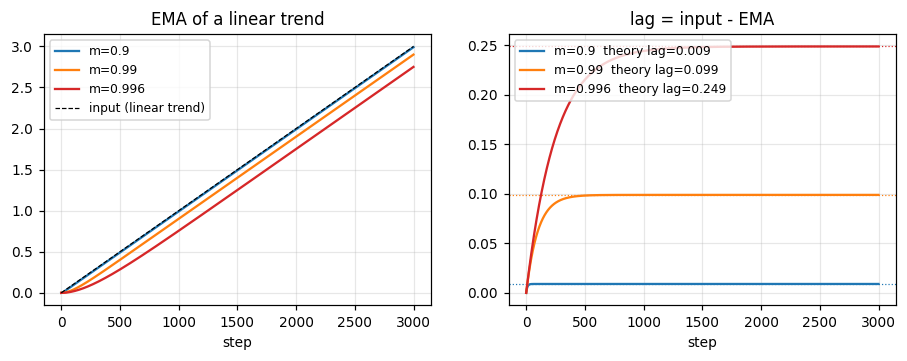

In [6]:
T = 3000
trend = 0.001 * np.arange(T)                       # 스텝당 0.001씩 증가
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for m, c in [(0.9, "C0"), (0.99, "C1"), (0.996, "C3")]:
    y = ema(trend, m)
    axes[0].plot(y, c=c, label=f"m={m}")
    axes[1].plot(trend - y, c=c, label=f"m={m}  theory lag={0.001 * m / (1 - m):.3f}")
    axes[1].axhline(0.001 * m / (1 - m), c=c, ls=":", lw=.8)
axes[0].plot(trend, "k--", lw=.8, label="input (linear trend)")
axes[0].set_title("EMA of a linear trend"); axes[0].set_xlabel("step")
axes[1].set_title("lag = input - EMA"); axes[1].set_xlabel("step")
for ax in axes: ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

### 초기화 편향

$y_0 = 0$ 에서 시작하면 초반 EMA는 참값보다 $m^t$ 비율만큼 0에 끌려 있다 (Adam이 $\hat{v}_t = v_t/(1-\beta^t)$ 로 나눠 보정하는 바로 그 편향).
DINO는 보정식 대신 **teacher를 student의 복사본으로 시작**한다:

```python
teacher.load_state_dict(student.module.state_dict())   # main_dino.py:208
```

첫 스텝부터 $y_0 = x_0$ 이므로 편향이 없다. 두 초기화를 비교해 보자.

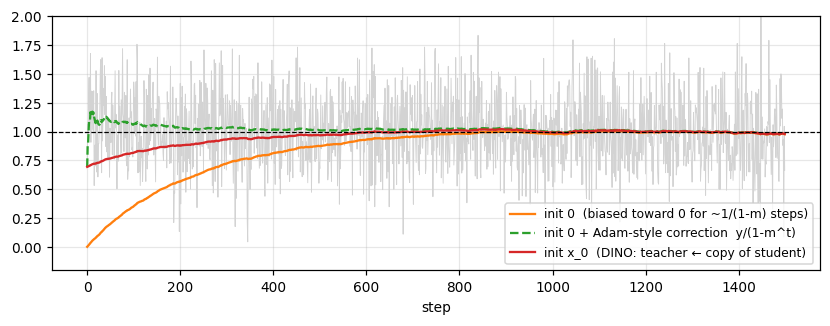

In [7]:
x = 1.0 + np.random.randn(1500) * 0.3
m = 0.996
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x, c="lightgray", lw=.6)
ax.plot(ema(x, m, init=0.0), c="C1", label="init 0  (biased toward 0 for ~1/(1-m) steps)")
ax.plot(ema(x, m, init=0.0) / (1 - m ** np.arange(1, 1501)), c="C2", ls="--", label="init 0 + Adam-style correction  y/(1-m^t)")
ax.plot(ema(x, m), c="C3", label="init x_0  (DINO: teacher ← copy of student)")
ax.axhline(1.0, c="k", ls="--", lw=.8); ax.set_ylim(-0.2, 2.0)
ax.set_xlabel("step"); ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.3)
plt.show()

## 4. 파라미터 EMA — 원본 코드 한 줄을 1:1로

지금까지는 스칼라였다. 원본은 **모든 파라미터 텐서에 대해 원소별로** 같은 식을 적용한다:

```python
# main_dino.py:346-350
with torch.no_grad():
    m = momentum_schedule[it]
    for param_q, param_k in zip(student.module.parameters(), teacher_without_ddp.parameters()):
        param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)
```

- `zip(parameters(), parameters())` — 두 모델이 **같은 구조·같은 순서**라는 가정. student/teacher는 같은 클래스에서 만든다.
- `torch.no_grad()` + `.detach()` — 이 갱신은 학습이 아니다. autograd 그래프에 남지 않는다.
- `mul_` / `add_` — in-place. teacher 파라미터 텐서 객체는 그대로 두고 값만 바꾼다.

작은 MLP로 재현하고, 평탄화(flatten)한 벡터에 스칼라 식을 적용한 것과 같은지 확인한다.

In [8]:
def make_net():
    return nn.Sequential(nn.Linear(4, 16), nn.GELU(), nn.Linear(16, 3))

def ema_update(student, teacher, m):
    """main_dino.py:346-350 과 동일"""
    with torch.no_grad():
        for param_q, param_k in zip(student.parameters(), teacher.parameters()):
            param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)

def flat(net):
    return torch.cat([p.detach().flatten() for p in net.parameters()])

student = make_net()
teacher = copy.deepcopy(student)                    # teacher.load_state_dict(student.state_dict()) 와 같음
for p in teacher.parameters():
    p.requires_grad = False                         # main_dino.py:211 — teacher는 gradient 없음

print("초기: |teacher - student| =", (flat(teacher) - flat(student)).norm().item())

# student를 임의로 "학습"시킨 셈 치고 (노이즈 추가) EMA 한 스텝
t_before = flat(teacher).clone()
with torch.no_grad():
    for p in student.parameters():
        p.add_(torch.randn_like(p) * 0.1)
s_after = flat(student).clone()

ema_update(student, teacher, m=0.9)
expected = 0.9 * t_before + 0.1 * s_after
print("한 스텝 후 원소별 식과의 최대 오차 :", (flat(teacher) - expected).abs().max().item())
print("teacher가 student 쪽으로 이동한 비율:",
      ((flat(teacher) - t_before).norm() / (s_after - t_before).norm()).item(), " (= 1-m)")

초기: |teacher - student| = 0.0
한 스텝 후 원소별 식과의 최대 오차 : 0.0
teacher가 student 쪽으로 이동한 비율: 0.09999999403953552  (= 1-m)


`requires_grad=False`인 teacher 파라미터도 `.data`로 갱신되는 것에 주의하자. teacher는 **역전파로는 절대 배우지 않고, 오직 이 EMA로만** 바뀐다.
teacher의 loss는 어디에도 없다 — `DINOLoss`는 `teacher_output.detach()`로 teacher 쪽 그래프를 끊는다.

## 5. 토이 실험 — EMA teacher는 왜 student보다 좋은 모델인가

논문 §5.2는 "학습 내내 teacher가 student보다 성능이 좋다"고 보고하고, 이를 **Polyak–Ruppert 평균**(SGD 궤적의 평균 = 일종의 모델 앙상블)으로 해석한다.

이 현상을 가장 단순한 설정에서 재현한다: 노이즈 있는 선형 회귀를 **작은 배치 + 큰 learning rate**의 SGD로 학습한다.
student 파라미터는 최적점 주위에서 계속 튀고, 그것의 EMA(teacher)가 최적점에 얼마나 더 가까운지 본다.

- $w^*$: 참 파라미터. 평가 지표 = $\|w - w^*\|$
- student: 매 스텝 배치 4개로 SGD
- teacher(m): student의 EMA. $m \in \{0, 0.9, 0.99, 0.999\}$. **$m=0$은 "teacher = student 복사"** (모멘텀 없음)

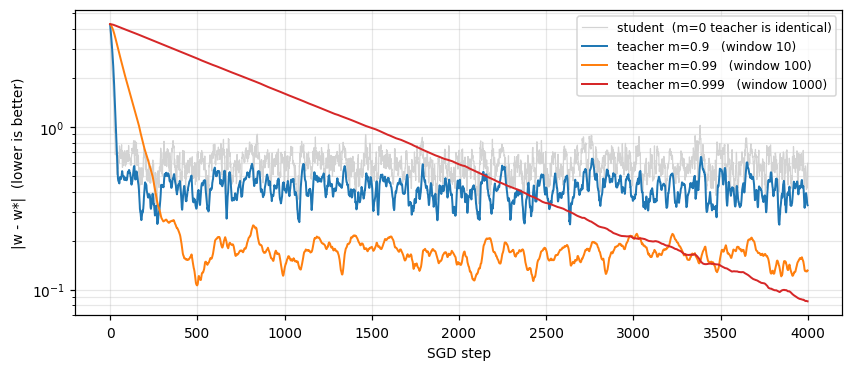

마지막 500 스텝 평균 |w - w*|
  student        : 0.5892
  teacher m=0.9  : 0.4131
  teacher m=0.99 : 0.1582
  teacher m=0.999: 0.1102


In [9]:
d, n_steps, bs, lr = 20, 4000, 4, 0.05
w_star = torch.randn(d)
X_all = torch.randn(200_000, d)
y_all = X_all @ w_star + torch.randn(200_000) * 1.0   # 관측 노이즈 std 1.0

momenta = [0.0, 0.9, 0.99, 0.999]
w_s = torch.zeros(d)                                # student
w_t = {m: w_s.clone() for m in momenta}             # teacher들 (student 복사본으로 시작)
dist_s, dist_t = [], {m: [] for m in momenta}

for it in range(n_steps):
    idx = torch.randint(0, len(X_all), (bs,))
    Xb, yb = X_all[idx], y_all[idx]
    grad = 2 * Xb.T @ (Xb @ w_s - yb) / bs           # MSE gradient
    w_s = w_s - lr * grad                            # student: 한 스텝 SGD
    for m in momenta:
        w_t[m] = m * w_t[m] + (1 - m) * w_s          # teacher: EMA (원본 한 줄과 동일)
        dist_t[m].append((w_t[m] - w_star).norm().item())
    dist_s.append((w_s - w_star).norm().item())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(dist_s, c="lightgray", lw=.8, label="student  (m=0 teacher is identical)")
for m, c in zip(momenta[1:], ["C0", "C1", "C3"]):
    ax.plot(dist_t[m], c=c, lw=1.3, label=f"teacher m={m}   (window {window(m):.0f})")
ax.set_yscale("log"); ax.set_xlabel("SGD step"); ax.set_ylabel("|w - w*|  (lower is better)")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")
plt.show()

print("마지막 500 스텝 평균 |w - w*|")
print(f"  student        : {np.mean(dist_s[-500:]):.4f}")
for m in momenta[1:]:
    print(f"  teacher m={m:<5}: {np.mean(dist_t[m][-500:]):.4f}")

읽는 법:

- **student(회색)** 는 최적점 근처에서 계속 튄다. 배치가 작고 lr이 커서 SGD 노이즈가 크다.
- **teacher m=0.99** 는 student보다 최적점에 **몇 배 가깝다**. 튀는 student들을 평균하면 노이즈가 상쇄되기 때문 (1절의 $\sqrt{(1-m)/(1+m)}$).
  이것이 "EMA teacher = 공짜 앙상블"이다.
- **teacher m=0.999** 는 초반에 student보다 **나쁘다** — 창(1000 스텝)이 너무 길어 아직 0 근처의 옛 student를 많이 기억한다(3절의 lag).
  충분히 지나면 가장 좋아진다.
- **m=0(복사)** 은 student와 같다. 아무 이득이 없다.

즉 $m$은 **"노이즈 제거(높을수록 좋음) vs 최신성(낮을수록 좋음)"** 의 트레이드오프다.
학습 초반엔 student가 빨리 움직이니 최신성이 중요하고, 후반엔 최적점 주위를 맴도니 노이즈 제거가 중요하다.
→ 그래서 DINO는 $m$을 **학습이 진행되며 올린다**. 다음 절.

> DINO에서 EMA teacher의 역할은 이 "더 좋은 모델"에 그치지 않는다. 논문 Table 2 ablation에서 momentum encoder를 빼면(teacher = student 복사)
> **학습 자체가 실패(collapse)** 한다. student가 매 스텝 바뀌는 자기 자신을 target으로 삼으면 붕괴를 막을 anchor가 없기 때문이다.
> 느리게 움직이는 teacher는 student에게 "몇백 스텝 전 합의된 목표"를 제공한다.

## 6. 모멘텀 스케줄 — 0.996 → 1, cosine

```python
# main_dino.py:249-251
momentum_schedule = utils.cosine_scheduler(args.momentum_teacher, 1,
                                           args.epochs, len(data_loader))
...
m = momentum_schedule[it]     # it = 전체 학습 중 global iteration 번호
```

`utils.cosine_scheduler`는 lr / weight decay 스케줄과 같은 함수다. 여기선 warmup 없이 `base=0.996`에서 `final=1`로 cosine 곡선을 따라 올라간다.
ImageNet 기본 설정(100 epoch, 배치 1024 → 1251 iter/epoch)으로 그려 보자.

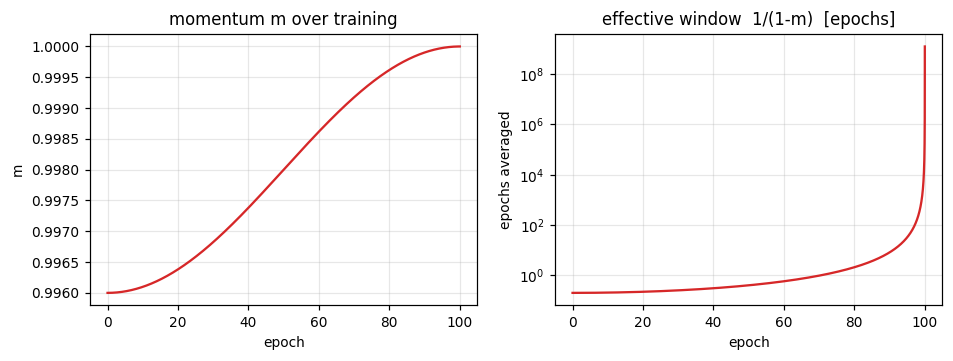

epoch   0: m=0.996000  window=       250 iter =    0.20 epoch
epoch  25: m=0.996586  window=       293 iter =    0.23 epoch
epoch  50: m=0.998000  window=       500 iter =    0.40 epoch
epoch  75: m=0.999414  window=      1707 iter =    1.36 epoch
epoch  90: m=0.999902  window=     10216 iter =    8.17 epoch
epoch  99: m=0.999999  window=   1013295 iter =  809.99 epoch
마지막 iter : 1-m = 6.3e-13  (cos 끝점이라 정확히 1은 아니지만 teacher는 사실상 정지)


In [10]:
epochs, niter_per_ep = 100, 1281167 // 1024
sched = utils.cosine_scheduler(0.996, 1, epochs, niter_per_ep)      # 원본 함수 그대로
it_axis = np.arange(len(sched)) / niter_per_ep                       # epoch 단위

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(it_axis, sched, c="C3"); axes[0].set_title("momentum m over training")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("m")
axes[1].plot(it_axis, 1 / (1 - sched) / niter_per_ep, c="C3")
axes[1].set_yscale("log"); axes[1].set_title("effective window  1/(1-m)  [epochs]")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("epochs averaged")
for ax in axes: ax.grid(alpha=.3, which="both")
plt.show()

for ep in [0, 25, 50, 75, 90, 99]:
    m = sched[ep * niter_per_ep]
    print(f"epoch {ep:>3}: m={m:.6f}  window={1/(1-m):>10.0f} iter = {1/(1-m)/niter_per_ep:>7.2f} epoch")
print(f"마지막 iter : 1-m = {1 - sched[-1]:.1e}  (cos 끝점이라 정확히 1은 아니지만 teacher는 사실상 정지)")

5절의 트레이드오프가 그대로 스케줄에 박혀 있다.

- **초반** $m$=0.996 → 창 0.2 epoch. student가 빨리 변하므로 teacher도 빨리 따라간다.
- **후반** $m$→1 → 창이 수십 epoch으로 늘어나 teacher는 사실상 **student 궤적 전체의 평균**으로 수렴한다. 마지막에는 거의 멈춘다.
- 최종 체크포인트의 `teacher`가 곧 "학습 후반 student들의 앙상블"이다. 평가는 teacher로 한다 (`eval_knn.py --checkpoint_key teacher`).

### 배치 크기가 작으면 $m$을 올려라 — 왜?

`--momentum_teacher` 도움말: *"small batches: for example use 0.9995 with batch size of 256"*. 두 가지 이유가 겹친다.

1. **배치가 작으면 한 스텝의 student 변화가 더 노이즈**다 → 더 많이 평균해야 같은 품질.
2. **배치가 작으면 1 epoch에 iter가 더 많다** → 같은 "epoch 단위 창"을 유지하려면 iter 단위 창이 길어야 한다.

"창을 이미지 수로 환산"하면 두 설정이 비슷한 규모임을 볼 수 있다.

In [11]:
print(f"{'batch':>6} {'m':>7} {'window(iter)':>13} {'window(images)':>15} {'window(epoch)':>14}")
for bs, m in [(1024, 0.996), (256, 0.9995), (256, 0.996), (64, 0.9995)]:
    w = window(m)
    print(f"{bs:>6} {m:>7} {w:>13.0f} {w * bs:>15,.0f} {w * bs / 1281167:>14.2f}")

 batch       m  window(iter)  window(images)  window(epoch)
  1024   0.996           250         256,000           0.20
   256  0.9995          2000         512,000           0.40
   256   0.996           250          64,000           0.05
    64  0.9995          2000         128,000           0.10


배치 256에서 $m$=0.996을 그대로 쓰면 창이 64k 이미지(0.05 epoch)로 너무 짧아져 teacher가 student와 거의 같아지고, 5절에서 본 앙상블 이득과 안정화 효과를 잃는다.
0.9995로 올리면 512k 이미지(0.4 epoch)로 기본 설정(256k)과 같은 자릿수가 된다.

## 7. center의 EMA — 같은 식, 전혀 다른 $m$=0.9

```python
# main_dino.py:406-416  DINOLoss.update_center
batch_center = torch.sum(teacher_output, dim=0, keepdim=True)
dist.all_reduce(batch_center)
batch_center = batch_center / (len(teacher_output) * dist.get_world_size())   # 전체 배치 평균
self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)
```

식은 4절과 같다. 그런데 `center_momentum=0.9` → 창이 **10 배치**밖에 안 된다. teacher 파라미터(250 iter)와 25배 차이. 왜?

| | teacher 파라미터 EMA | center EMA |
|---|---|---|
| 입력 $x_t$ | student 파라미터 (SGD 노이즈 큼) | teacher 출력의 **배치 평균** (이미 B×world 개를 평균해 노이즈 작음) |
| 입력이 움직이는 속도 | 느림 (한 스텝 lr만큼) | 빠름 — teacher 출력 분포는 학습 중 계속 이동 |
| 원하는 것 | 노이즈 제거 (앙상블) | **현재 출력 분포의 평균을 정확히 추적** |
| 뒤처지면 | 조금 옛 모델 — 큰 문제 아님 | 빼야 할 평균을 못 빼서 **centering 실패 → 원-핫 붕괴 위험** |

즉 center는 노이즈 제거보다 **추적**이 목적이라 창이 짧아야 한다. 드리프트하는 신호를 두 $m$으로 추적해 보자.

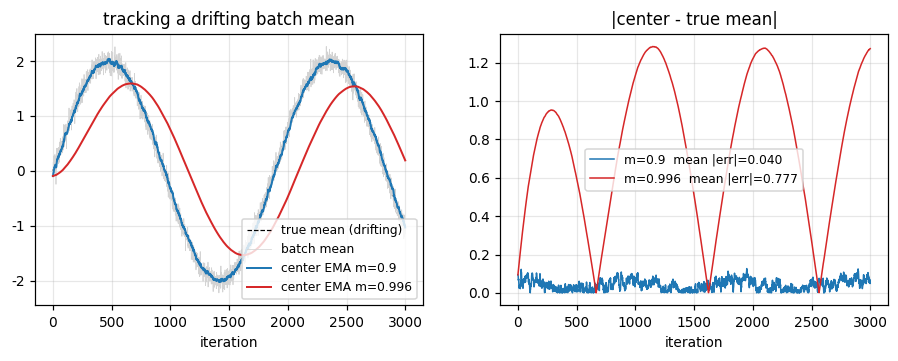

In [12]:
T = 3000
true_mean = 2.0 * np.sin(np.arange(T) / 300)                  # 천천히 이동하는 "출력 분포의 평균"
batch_means = true_mean + np.random.randn(T) * 0.1            # 배치 평균 (B개 평균이라 노이즈 작음)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(true_mean, "k--", lw=.8, label="true mean (drifting)")
axes[0].plot(batch_means, c="lightgray", lw=.5, label="batch mean")
for m, c in [(0.9, "C0"), (0.996, "C3")]:
    y = ema(batch_means, m)
    axes[0].plot(y, c=c, lw=1.3, label=f"center EMA m={m}")
    axes[1].plot(np.abs(y - true_mean), c=c, lw=1, label=f"m={m}  mean |err|={np.abs(y - true_mean)[300:].mean():.3f}")
axes[0].set_title("tracking a drifting batch mean"); axes[0].set_xlabel("iteration")
axes[1].set_title("|center - true mean|"); axes[1].set_xlabel("iteration")
for ax in axes: ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

$m$=0.996이면 center가 참 평균을 한참 뒤에서 쫓아가 오차가 크다. 배치 평균은 이미 노이즈가 작으므로 $m$=0.9로 충분히 매끈하고, 추적도 빠르다.

**EMA의 $m$은 "높을수록 좋은" 값이 아니다.** 입력의 노이즈 크기와 이동 속도를 보고 정하는 값이다.

## 8. 요약

### EMA 한 장 정리

$$y_t = m\,y_{t-1} + (1-m)\,x_t \;=\; (1-m)\sum_k m^k x_{t-k}$$

| 성질 | 값 | DINO teacher ($m$=0.996) |
|---|---|---|
| 유효 창 | $1/(1-m)$ | 250 iter ≈ 0.2 epoch (배치 1024) |
| 노이즈 감쇠 (std 비율) | $\sqrt{(1-m)/(1+m)}$ | ×0.045 |
| 선형 추세 지연 | $c \cdot m/(1-m)$ | 249 스텝 전의 student |
| 초기화 | $y_0 = x_0$ (복사) | `teacher.load_state_dict(student...)` → 편향 없음 |

### teacher = student의 EMA인 이유 (세 가지가 겹친다)

1. **앙상블(Polyak 평균)** — SGD 노이즈를 상쇄해 student보다 좋은 모델이 된다 (5절, 논문 §5.2).
2. **안정한 target** — 매 스텝 바뀌는 student 대신 "최근 수백 스텝의 합의"를 target으로 준다. 빼면 collapse (논문 Table 2).
3. **추가 비용 없음** — 역전파 없이 `mul_/add_` 한 번. 별도 teacher 학습이 필요 없다.

### 스케줄과 하이퍼파라미터

- $m$: 0.996 → 1 cosine. 초반은 최신성, 후반은 노이즈 제거. 마지막 teacher = 후반 student들의 평균.
- 배치 작으면 $m$ ↑ (256이면 0.9995). "창을 이미지 수로 환산"해 기본 설정과 맞춘다.
- center는 **추적**이 목적 → $m$=0.9로 짧게.

### 원본 코드 대응

| 이 노트북 | 원본 |
|---|---|
| `ema()` / `ema_update()` | [main_dino.py:346](../main_dino.py#L346) `param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)` |
| `copy.deepcopy(student)` | [main_dino.py:208](../main_dino.py#L208) `teacher.load_state_dict(student.module.state_dict())` |
| `p.requires_grad = False` | [main_dino.py:211](../main_dino.py#L211) |
| `utils.cosine_scheduler(0.996, 1, ...)` | [main_dino.py:250](../main_dino.py#L250) `momentum_schedule`, [utils.py:187](../utils.py#L187) |
| 7절 `ema(batch_means, 0.9)` | [main_dino.py:416](../main_dino.py#L416) `update_center` |

### 실전 함정

1. **`parameters()`만 EMA된다. buffer는 아니다.** BatchNorm의 `running_mean/var`는 buffer라 이 루프에 안 들어간다.
   ResNet 백본이나 `--use_bn_in_head`를 쓰면 teacher의 BN 통계는 teacher 자체 forward(train 모드)로 따로 갱신된다.
   직접 EMA 모델을 만들 때 `state_dict()` 전체를 돌릴지, `parameters()`만 돌릴지 의식적으로 정해야 한다.
2. **`momentum_schedule[it]`의 `it`는 global iteration.** 재시작 시 `it = start_epoch * len(loader)`로 이어져야 스케줄이 맞는다.
   epoch 수나 배치 크기를 바꿔 재시작하면 `len(momentum_schedule)`도 바뀌어 `IndexError`가 날 수 있다.
3. **짧은 학습에서는 $m$이 1에 못 미친다.** 스모크 테스트(2 epoch, 15 iter)에서는 cosine이 15스텝 안에 0.996→1로 뛰어 teacher가 거의 초기값에 머문다.
   짧은 실험에서 teacher 성능이 이상하면 이것부터 의심.
4. **EMA는 fp32에서.** `--use_fp16`이어도 파라미터 자체는 fp32 master copy라 `mul_/add_`의 정밀도 손실은 없다.
   파라미터를 half로 저장하는 커스텀 구현에서는 $(1-m)=0.004$ 배 곱셈이 언더플로/반올림으로 사라질 수 있다.
5. **평가·배포는 teacher로.** `checkpoint.pth`에는 둘 다 저장된다. `--checkpoint_key teacher`.